开始处理所有实例并计算相对模型基准的 Gap...
处理完成，共计匹配到 1000 个有效实例。


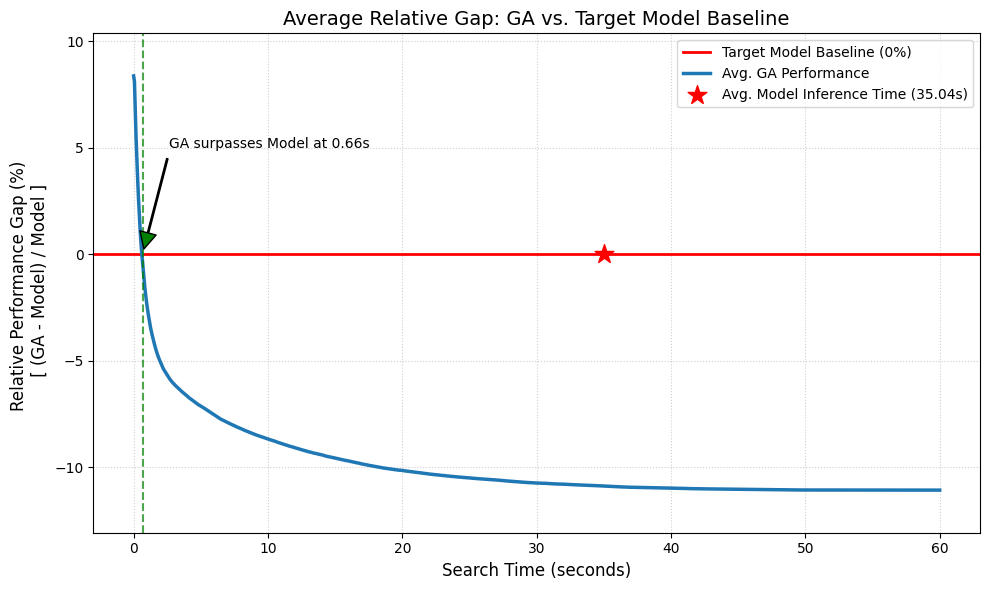

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ================= 配置区域 =================
ga_folder_path = 'GA_Benchmark_testset_large_History'  # GA历史文件所在文件夹
model_results_file = 'result_trainset_SL_Run_Fix_Batching_119_tmp_699_BS4.csv'
max_time_limit = 60  # 绘图显示的最大时间长度（秒）
# ===========================================

# 1. 读取模型结果
df_model_all = pd.read_csv(model_results_file)

# 2. 准备数据容器
all_relative_gaps = []
common_time_grid = np.linspace(0, max_time_limit, 1000) # 统一时间网格

print("开始处理所有实例并计算相对模型基准的 Gap...")

# 3. 遍历所有 GA 文件
history_files = glob.glob(os.path.join(ga_folder_path, "*.csv"))

valid_count = 0
for file_path in history_files:
    # 提取文件名进行匹配 (例如从 job100_m10_194_history.csv 提取出 job100_m10_194.json)
    base_name = os.path.basename(file_path).replace('_history.csv', '')
    json_name = base_name + '.json'
    
    # 获取该实例的模型结果
    model_row = df_model_all[df_model_all['Filename'] == json_name]
    if model_row.empty:
        continue
    
    model_makespan = model_row['Makespan'].values[0]
    
    # 读取GA历史
    df_ga = pd.read_csv(file_path)
    
    # --- 核心计算：以 Model Makespan 为基准的相对 Gap ---
    # Gap = (GA结果 - 模型结果) / 模型结果
    # 结果为正：GA比模型差；结果为负：GA比模型好
    df_ga['Rel_Gap'] = (df_ga['Best_Makespan'] - model_makespan) / model_makespan
    
    # 插值到统一的时间网格
    # 填充：如果GA运行时间短于max_time_limit，用最后一个值填充
    interp_gap = np.interp(common_time_grid, df_ga['Time(s)'], df_ga['Rel_Gap'])
    
    all_relative_gaps.append(interp_gap)
    valid_count += 1

print(f"处理完成，共计匹配到 {valid_count} 个有效实例。")

# 4. 计算平均 Gap 曲线
all_gaps_array = np.array(all_relative_gaps)
mean_gap_curve = np.mean(all_gaps_array, axis=0)
# 计算模型平均推理时间（作为图上的一个点参考）
avg_model_inference_time = df_model_all['Inference_Time(s)'].mean()

# 5. 绘图
plt.figure(figsize=(10, 6), dpi=100)

# 绘制基准线 (0% 处，代表模型表现)
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Target Model Baseline (0%)')

# 绘制平均 GA 相对曲线
plt.plot(common_time_grid, mean_gap_curve * 100, color='#1f77b4', linewidth=2.5, label='Avg. GA Performance')

# 标注模型推理时间点
plt.scatter(avg_model_inference_time, 0, color='red', marker='*', s=200, zorder=5, 
            label=f'Avg. Model Inference Time ({avg_model_inference_time:.2f}s)')

# 寻找穿过 0% 的交点（GA何时超越模型）
cross_idx = np.where(mean_gap_curve <= 0)[0]
if len(cross_idx) > 0:
    break_even_time = common_time_grid[cross_idx[0]]
    plt.axvline(x=break_even_time, color='green', linestyle='--', alpha=0.7)
    plt.annotate(f'GA surpasses Model at {break_even_time:.2f}s', 
                 xy=(break_even_time, 0), xytext=(break_even_time + 2, 5),
                 arrowprops=dict(facecolor='green', shrink=0.05, width=1))

# 设置格式
plt.title('Average Relative Gap: GA vs. Target Model Baseline', fontsize=14)
plt.xlabel('Search Time (seconds)', fontsize=12)
plt.ylabel('Relative Performance Gap (%) \n [ (GA - Model) / Model ]', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# 根据数据动态调整Y轴，让 0 线处于显眼位置
y_max = max(mean_gap_curve[0] * 100, 5)
y_min = min(mean_gap_curve[-1] * 100, -5)
plt.ylim(y_min - 2, y_max + 2)

plt.tight_layout()
plt.show()

开始处理所有实例并计算相对模型基准的 Gap...
处理完成，共计匹配到 1000 个有效实例。


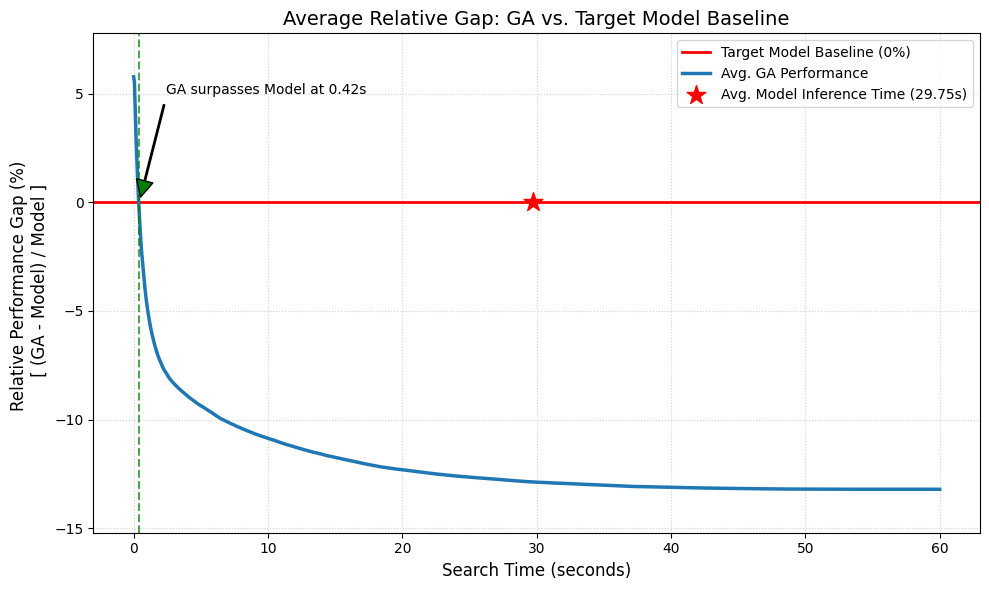

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ================= 配置区域 =================
ga_folder_path = 'GA_Benchmark_testset_large_History'  # GA历史文件所在文件夹
model_results_file = 'result_trainset_SL_Run_Fix_Batching_121_749_BS4_large.csv'
max_time_limit = 60  # 绘图显示的最大时间长度（秒）
# ===========================================

# 1. 读取模型结果
df_model_all = pd.read_csv(model_results_file)

# 2. 准备数据容器
all_relative_gaps = []
common_time_grid = np.linspace(0, max_time_limit, 1000) # 统一时间网格

print("开始处理所有实例并计算相对模型基准的 Gap...")

# 3. 遍历所有 GA 文件
history_files = glob.glob(os.path.join(ga_folder_path, "*.csv"))

valid_count = 0
for file_path in history_files:
    # 提取文件名进行匹配 (例如从 job100_m10_194_history.csv 提取出 job100_m10_194.json)
    base_name = os.path.basename(file_path).replace('_history.csv', '')
    json_name = base_name + '.json'
    
    # 获取该实例的模型结果
    model_row = df_model_all[df_model_all['Filename'] == json_name]
    if model_row.empty:
        continue
    
    model_makespan = model_row['Makespan'].values[0]
    
    # 读取GA历史
    df_ga = pd.read_csv(file_path)
    
    # --- 核心计算：以 Model Makespan 为基准的相对 Gap ---
    # Gap = (GA结果 - 模型结果) / 模型结果
    # 结果为正：GA比模型差；结果为负：GA比模型好
    df_ga['Rel_Gap'] = (df_ga['Best_Makespan'] - model_makespan) / model_makespan
    
    # 插值到统一的时间网格
    # 填充：如果GA运行时间短于max_time_limit，用最后一个值填充
    interp_gap = np.interp(common_time_grid, df_ga['Time(s)'], df_ga['Rel_Gap'])
    
    all_relative_gaps.append(interp_gap)
    valid_count += 1

print(f"处理完成，共计匹配到 {valid_count} 个有效实例。")

# 4. 计算平均 Gap 曲线
all_gaps_array = np.array(all_relative_gaps)
mean_gap_curve = np.mean(all_gaps_array, axis=0)
# 计算模型平均推理时间（作为图上的一个点参考）
avg_model_inference_time = df_model_all['Inference_Time(s)'].mean()

# 5. 绘图
plt.figure(figsize=(10, 6), dpi=100)

# 绘制基准线 (0% 处，代表模型表现)
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Target Model Baseline (0%)')

# 绘制平均 GA 相对曲线
plt.plot(common_time_grid, mean_gap_curve * 100, color='#1f77b4', linewidth=2.5, label='Avg. GA Performance')

# 标注模型推理时间点
plt.scatter(avg_model_inference_time, 0, color='red', marker='*', s=200, zorder=5, 
            label=f'Avg. Model Inference Time ({avg_model_inference_time:.2f}s)')

# 寻找穿过 0% 的交点（GA何时超越模型）
cross_idx = np.where(mean_gap_curve <= 0)[0]
if len(cross_idx) > 0:
    break_even_time = common_time_grid[cross_idx[0]]
    plt.axvline(x=break_even_time, color='green', linestyle='--', alpha=0.7)
    plt.annotate(f'GA surpasses Model at {break_even_time:.2f}s', 
                 xy=(break_even_time, 0), xytext=(break_even_time + 2, 5),
                 arrowprops=dict(facecolor='green', shrink=0.05, width=1))

# 设置格式
plt.title('Average Relative Gap: GA vs. Target Model Baseline', fontsize=14)
plt.xlabel('Search Time (seconds)', fontsize=12)
plt.ylabel('Relative Performance Gap (%) \n [ (GA - Model) / Model ]', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# 根据数据动态调整Y轴，让 0 线处于显眼位置
y_max = max(mean_gap_curve[0] * 100, 5)
y_min = min(mean_gap_curve[-1] * 100, -5)
plt.ylim(y_min - 2, y_max + 2)

plt.tight_layout()
plt.show()

开始处理所有实例并计算相对模型基准的 Gap...
处理完成，共计匹配到 1000 个有效实例。


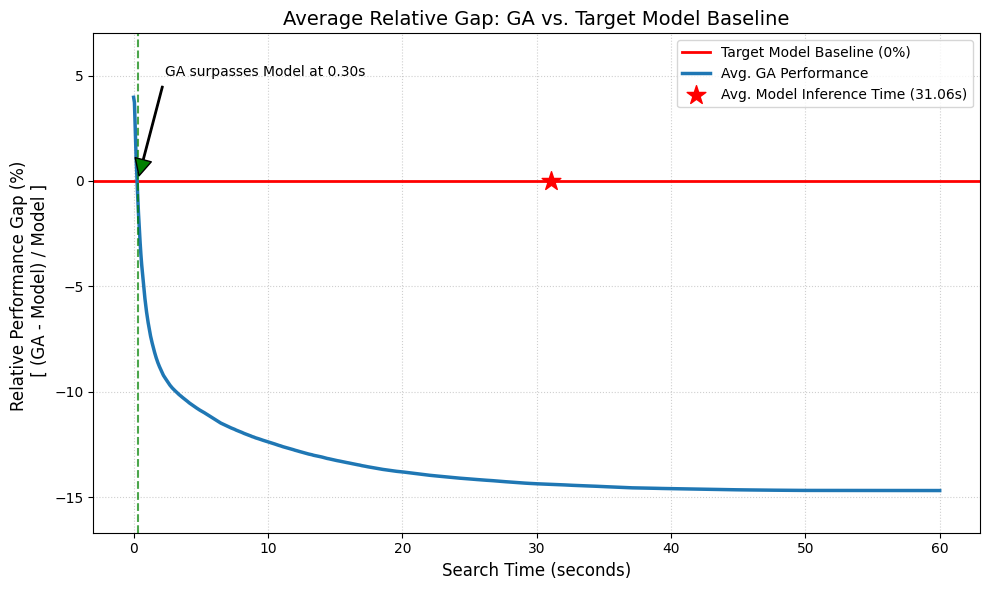

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ================= 配置区域 =================
ga_folder_path = 'GA_Benchmark_testset_large_History'  # GA历史文件所在文件夹
model_results_file = 'result_trainset_SL_Run_Fix_Batching_121_1749_BS4_large.csv'
max_time_limit = 60  # 绘图显示的最大时间长度（秒）
# ===========================================

# 1. 读取模型结果
df_model_all = pd.read_csv(model_results_file)

# 2. 准备数据容器
all_relative_gaps = []
common_time_grid = np.linspace(0, max_time_limit, 1000) # 统一时间网格

print("开始处理所有实例并计算相对模型基准的 Gap...")

# 3. 遍历所有 GA 文件
history_files = glob.glob(os.path.join(ga_folder_path, "*.csv"))

valid_count = 0
for file_path in history_files:
    # 提取文件名进行匹配 (例如从 job100_m10_194_history.csv 提取出 job100_m10_194.json)
    base_name = os.path.basename(file_path).replace('_history.csv', '')
    json_name = base_name + '.json'
    
    # 获取该实例的模型结果
    model_row = df_model_all[df_model_all['Filename'] == json_name]
    if model_row.empty:
        continue
    
    model_makespan = model_row['Makespan'].values[0]
    
    # 读取GA历史
    df_ga = pd.read_csv(file_path)
    
    # --- 核心计算：以 Model Makespan 为基准的相对 Gap ---
    # Gap = (GA结果 - 模型结果) / 模型结果
    # 结果为正：GA比模型差；结果为负：GA比模型好
    df_ga['Rel_Gap'] = (df_ga['Best_Makespan'] - model_makespan) / model_makespan
    
    # 插值到统一的时间网格
    # 填充：如果GA运行时间短于max_time_limit，用最后一个值填充
    interp_gap = np.interp(common_time_grid, df_ga['Time(s)'], df_ga['Rel_Gap'])
    
    all_relative_gaps.append(interp_gap)
    valid_count += 1

print(f"处理完成，共计匹配到 {valid_count} 个有效实例。")

# 4. 计算平均 Gap 曲线
all_gaps_array = np.array(all_relative_gaps)
mean_gap_curve = np.mean(all_gaps_array, axis=0)
# 计算模型平均推理时间（作为图上的一个点参考）
avg_model_inference_time = df_model_all['Inference_Time(s)'].mean()

# 5. 绘图
plt.figure(figsize=(10, 6), dpi=100)

# 绘制基准线 (0% 处，代表模型表现)
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Target Model Baseline (0%)')

# 绘制平均 GA 相对曲线
plt.plot(common_time_grid, mean_gap_curve * 100, color='#1f77b4', linewidth=2.5, label='Avg. GA Performance')

# 标注模型推理时间点
plt.scatter(avg_model_inference_time, 0, color='red', marker='*', s=200, zorder=5, 
            label=f'Avg. Model Inference Time ({avg_model_inference_time:.2f}s)')

# 寻找穿过 0% 的交点（GA何时超越模型）
cross_idx = np.where(mean_gap_curve <= 0)[0]
if len(cross_idx) > 0:
    break_even_time = common_time_grid[cross_idx[0]]
    plt.axvline(x=break_even_time, color='green', linestyle='--', alpha=0.7)
    plt.annotate(f'GA surpasses Model at {break_even_time:.2f}s', 
                 xy=(break_even_time, 0), xytext=(break_even_time + 2, 5),
                 arrowprops=dict(facecolor='green', shrink=0.05, width=1))

# 设置格式
plt.title('Average Relative Gap: GA vs. Target Model Baseline', fontsize=14)
plt.xlabel('Search Time (seconds)', fontsize=12)
plt.ylabel('Relative Performance Gap (%) \n [ (GA - Model) / Model ]', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# 根据数据动态调整Y轴，让 0 线处于显眼位置
y_max = max(mean_gap_curve[0] * 100, 5)
y_min = min(mean_gap_curve[-1] * 100, -5)
plt.ylim(y_min - 2, y_max + 2)

plt.tight_layout()
plt.show()

开始处理 1000 个文件，当前设定 T_sim = 0.5s...


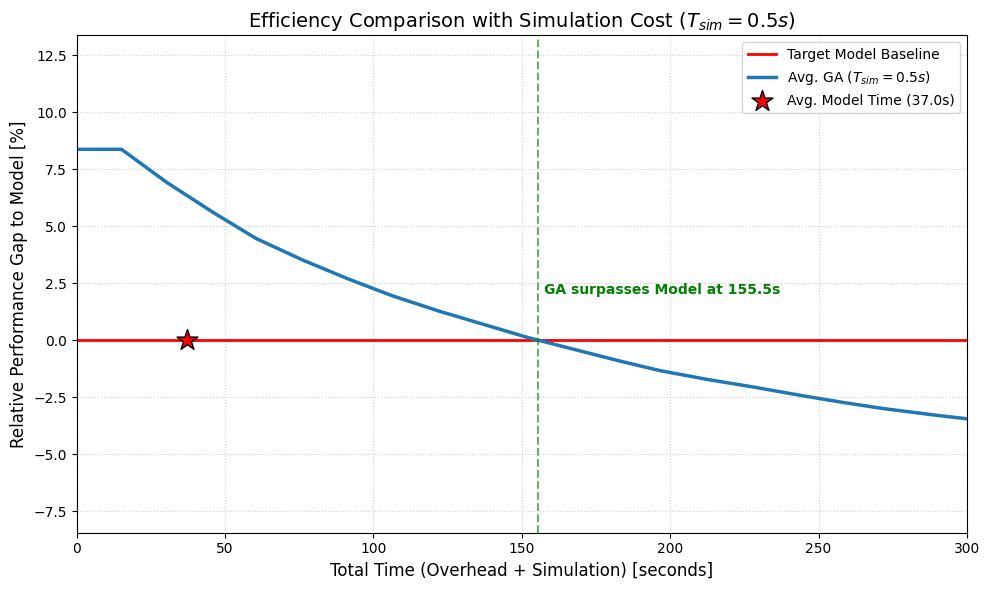

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ================= 配置区域 =================
ga_folder_path = 'GA_Benchmark_testset_large_History'  # GA历史文件夹路径
model_results_file = 'result_trainset_SL_Run_Fix_Batching_119_tmp_699_BS4.csv'

# --- 设定仿真参数 ---
T_sim = 0.5            # <--- 在这里设定你的仿真时长 (单位: 秒/次)
sims_per_gen_ga = 30   # GA 每一代需要的仿真次数
total_sims_model = 4   # 目标模型总共需要的仿真次数

max_plot_time = 300    # 绘图时间轴上限 (根据 T_sim 大小手动调整)
# ===========================================

# 1. 读取模型结果
df_model_all = pd.read_csv(model_results_file)
history_files = glob.glob(os.path.join(ga_folder_path, "*.csv"))

# 准备数据容器
all_relative_gaps = []
model_times = []
common_time_grid = np.linspace(0, max_plot_time, 2000)

print(f"开始处理 {len(history_files)} 个文件，当前设定 T_sim = {T_sim}s...")

# 2. 遍历处理所有实例
for file_path in history_files:
    base_name = os.path.basename(file_path).replace('_history.csv', '')
    json_name = base_name + '.json'
    
    model_row = df_model_all[df_model_all['Filename'] == json_name]
    if model_row.empty: continue
    
    # 提取模型数据并计算调整后的时间
    model_makespan = model_row['Makespan'].values[0]
    model_inf_time = model_row['Inference_Time(s)'].values[0]
    model_times.append(model_inf_time + total_sims_model * T_sim)
    
    # 读取 GA 历史并调整时间轴
    df_ga = pd.read_csv(file_path)
    # 调整公式：原算法耗时 + (代数+1) * 每代仿真数 * 单次仿真时长
    adj_ga_time = df_ga['Time(s)'] + (df_ga['Generation'] + 1) * sims_per_gen_ga * T_sim
    
    # 计算相对于该实例模型结果的 Gap
    rel_gap = (df_ga['Best_Makespan'] - model_makespan) / model_makespan
    
    # 插值对齐
    interp_gap = np.interp(common_time_grid, adj_ga_time, rel_gap)
    all_relative_gaps.append(interp_gap)

# 3. 计算统计值
mean_gap_curve = np.mean(all_relative_gaps, axis=0)
avg_model_time = np.mean(model_times)

# 4. 绘图
plt.figure(figsize=(10, 6), dpi=100)

# 绘制 0% 基准线（代表模型水平）
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Target Model Baseline')

# 绘制调整时间后的 GA 平均收敛曲线
plt.plot(common_time_grid, mean_gap_curve * 100, color='#1f77b4', linewidth=2.5, label=f'Avg. GA ($T_{{sim}}={T_sim}s$)')

# 标注模型在平均用时处的位置（红星）
plt.scatter(avg_model_time, 0, color='red', marker='*', s=250, edgecolors='black', zorder=5, 
            label=f'Avg. Model Time ({avg_model_time:.1f}s)')

# 寻找并标注 GA 追平模型的时间点
cross_idx = np.where(mean_gap_curve <= 0)[0]
if len(cross_idx) > 0:
    break_even_time = common_time_grid[cross_idx[0]]
    plt.axvline(x=break_even_time, color='green', linestyle='--', alpha=0.6)
    plt.text(break_even_time + 2, 2, f'GA surpasses Model at {break_even_time:.1f}s', color='green', fontweight='bold')

# 图表装饰
plt.title(f'Efficiency Comparison with Simulation Cost ($T_{{sim}} = {T_sim}s$)', fontsize=14)
plt.xlabel('Total Time (Overhead + Simulation) [seconds]', fontsize=12)
plt.ylabel('Relative Performance Gap to Model [%]', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.xlim(0, max_plot_time)

# 动态调整 Y 轴范围
plt.ylim(min(mean_gap_curve)*100 - 5, max(mean_gap_curve[0]*100, 5) + 5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_490/469233223.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(plot_data, labels=labels, patch_artist=True,
/tmp/ipykernel_490/469233223.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


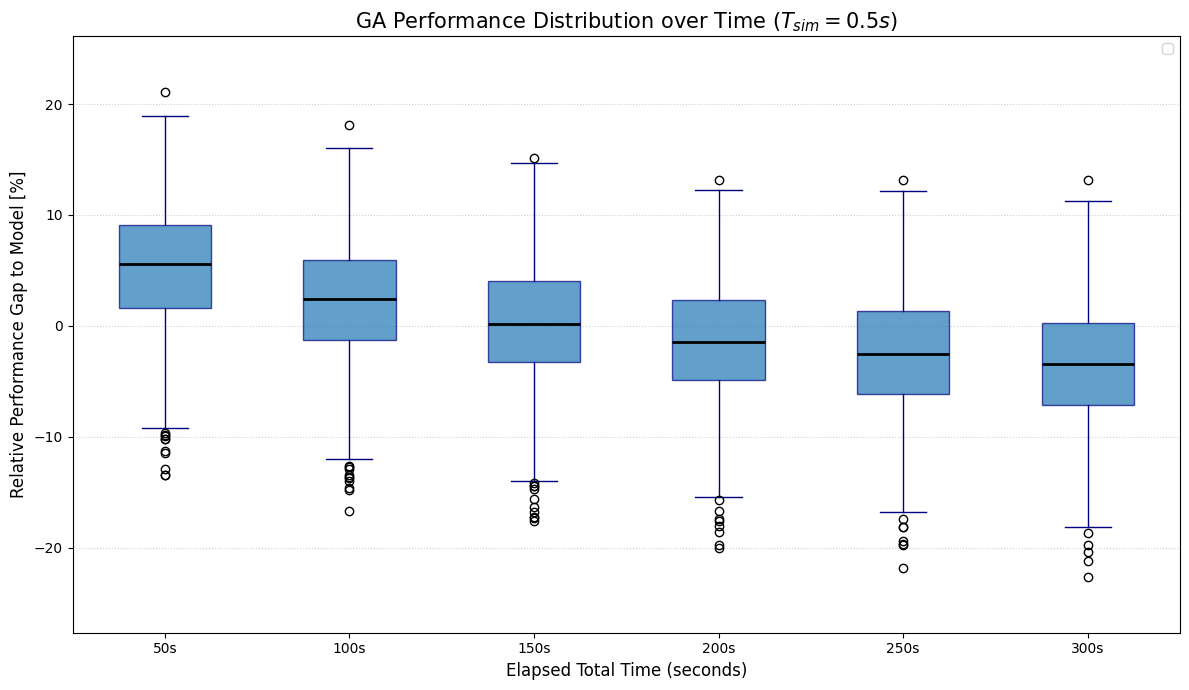

In [4]:
# ================= 修改后的绘图与统计区域 =================
import seaborn as sns

# 1. 设置采样时间点 (每 50 秒一个点)
interval = 50 
time_points = np.arange(interval, max_plot_time + interval, interval)

# 2. 提取对应时间点的 Gap 数据
# all_relative_gaps 形状为 (实例数, 2000)，我们需要找到 common_time_grid 中最接近 time_points 的索引
plot_data = []
labels = []

all_gaps_array = np.array(all_relative_gaps) * 100  # 转为百分比

for tp in time_points:
    if tp > max_plot_time: break
    # 找到最接近该时间点的索引
    idx = np.abs(common_time_grid - tp).argmin()
    # 提取所有实例在该时间点的 Gap
    gaps_at_t = all_gaps_array[:, idx]
    plot_data.append(gaps_at_t)
    labels.append(f"{tp}s")

# 3. 开始绘图
plt.figure(figsize=(12, 7), dpi=100)

# 绘制箱型图
# patch_artist=True 允许填充颜色，showfliers=False 可以隐藏异常值点（让图表更干净）
bplot = plt.boxplot(plot_data, labels=labels, patch_artist=True, 
                    medianprops={'color': 'black', 'linewidth': 2},
                    boxprops={'facecolor': '#1f77b4', 'edgecolor': 'navy', 'alpha': 0.7},
                    whiskerprops={'color': 'navy'},
                    capprops={'color': 'navy'},
                    showfliers=True) # 如果想看极端情况，设为 True

# # 绘制模型基准线 (0% Gap)
# plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Target Model Baseline')

# 标注平均模型耗时
avg_model_time = np.mean(model_times)
# 计算平均模型耗时在箱型图 X 轴上的大致位置
# plt.scatter(avg_model_time / interval, 0, color='red', marker='*', s=300, 
#             edgecolors='black', zorder=10, label=f'Avg. Model Time ({avg_model_time:.1f}s)')

# 图表修饰
plt.title(f'GA Performance Distribution over Time ($T_{{sim}} = {T_sim}s$)', fontsize=15)
plt.xlabel('Elapsed Total Time (seconds)', fontsize=12)
plt.ylabel('Relative Performance Gap to Model [%]', fontsize=12)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

# 动态调整 Y 轴，确保能看到模型基准线
all_values = np.concatenate(plot_data)
plt.ylim(min(all_values) - 5, max(all_values) + 5)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

正在读取文件: SPT_checkpoints/SL_Run_Fix_Batching_121/training_log.txt


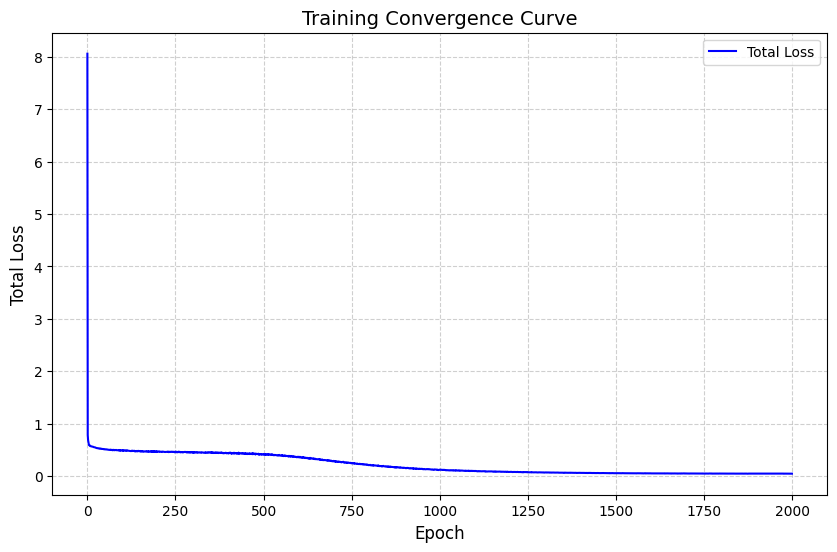

曲线图已绘制并保存为 convergence_curve_full.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# 1. 自动获取当前目录下第一个 txt 文件
file_name = 'SPT_checkpoints/SL_Run_Fix_Batching_121/training_log.txt'

if not file_name:
    print("未找到 txt 文件，请确保文件在当前目录下。")
else:
    print(f"正在读取文件: {file_name}")

    # 2. 读取数据 (假设是以逗号分隔的 CSV 格式)
    # 如果你的文件是用空格或制表符分隔的，可以修改 sep 参数，例如 sep='\s+'
    df = pd.read_csv(file_name)

    # 3. 绘制收敛曲线
    plt.figure(figsize=(10, 6))
    plt.plot(df['Epoch'], df['Total_Loss'], label='Total Loss', color='blue', linewidth=1.5)
    
    # 装饰图表
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Total Loss', fontsize=12)
    plt.title('Training Convergence Curve', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # 保存并显示
    # plt.savefig('convergence_curve_full.png', dpi=300)
    plt.show()
    
    print("曲线图已绘制并保存为 convergence_curve_full.png")